In [1]:
import os
import json
import time
import argparse
from typing import Tuple, Optional
import re

import numpy as np
from scipy.optimize import minimize

#few and SEF imports
from few.waveform import GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import KerrEccEqFlux
from few.utils.geodesic import get_fundamental_frequencies
from scipy.interpolate import CubicSpline
from scipy.integrate import cumulative_trapezoid
from few.utils.constants import MTSUN_SI

from fastlisaresponse import ResponseWrapper
from lisatools.detector import EqualArmlengthOrbits
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from stableemrifisher.utils import generate_PSD, inner_product
from stableemrifisher.fisher import StableEMRIFisher
import matplotlib.pyplot as plt

from config_paris import Config, ObjectiveTracker
from misc import *
try:
    import cupy as cp
    xp=cp
except:
    xp=np
    print("CuPy not found, using NumPy instead. For GPU acceleration, please install CuPy.")

from inference import  prepare_true_waveform
# from analyze import plot_frequency_series, plot_time_series

startup


In [ ]:
seed= 42   
param_names_to_infer = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0']  
params_name = ["m1","m2","a","p0","e0","xI0","dist","qS","phiS","qK","phiK",
                         "Phi_phi0","Phi_theta0","Phi_r0"]      

params = np.array([1.00000000e+06, 1.00000000e+01, 5.00000000e-01, 1.00469014e+01,
       1.00000000e-01, 1.00000000e+00, 3.87879918e+00, 1.04719755e+00,
       7.85398163e-01, 6.28318531e-01, 5.23598776e-01, 1.00000000e-01,
       2.00000000e-01, 3.00000000e-01])

# signal_param = {"m1": 1e6,"m2": 10.0,"a": 0.9,"p0": 7.5,"e0": 0.5,"xI0": 1.0,
#     "dist": 5.0,
#     "qS": np.pi/4,
#     "phiS": 1,
#     "qK": 1,
#     "phiK": np.pi/3,
#     "Phi_phi0": 0.9,
#     "Phi_theta0": 0.5,
#     "Phi_r0": 4.00000000e-01,
# }
signal_param_array = params
dt = 10  #Time step for waveform generation; default 0.1s
T= 2.5

chi2 = .95
dev_1 = 0.0
dev_2 = 0.0

emri_kwargs = {"T": T, "dt": dt,'chi2': chi2,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': False,
                   'dev_1': dev_1, 'dev_2': dev_2}
add_kwargs = {'chi2': chi2,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': False,
                   'dev_1': dev_1, 'dev_2':  dev_2}

# if target_func in ('optimal_snr', 'optimal_snr_phase_max','time_max'):
        
ctx_m = prepare_true_waveform(signal_param_array, emri_kwargs, add_kwargs,add_noise=False, use_gpu=True,seed=seed)

snr_2 = inner_prod(ctx_m['waveform_true_fft_without_noise'], ctx_m['waveform_true_fft_without_noise'], ctx_m['PSD_funcs'], ctx_m['delta_f'], xp=xp)
ctx_m

[INFO] Finished loading modules and building ResponseWrapper
[INFO] Finished generating true waveform
shape check - waveform_true: (3, 7889537) PSD_funcs: (3, 3944768)
[TRUE] SNR: 44.815162
[TRUE] SNR - Channel 0: 31.564311
[TRUE] SNR - Channel 1: 31.813282
[TRUE] SNR - Channel 2: 0.090409
[INFO] Frequency resolution delta_f: 1.267502e-08 Hz, Number of frequency bins: 3944769
freq_max: 0.050000 Hz and Freq_min: 0.000000 Hz
[INFO] No noise added to true waveform FFT

[INFO] Finished preparing true waveform (GPU)


{'m1': np.float64(1000000.0),
 'm2': np.float64(10.0),
 'a': np.float64(0.5),
 'p0': np.float64(10.0469014),
 'e0': np.float64(0.1),
 'Y0': np.float64(1.0),
 'dist': np.float64(3.87879918),
 'qS': np.float64(1.04719755),
 'phiS': np.float64(0.785398163),
 'qK': np.float64(0.628318531),
 'phiK': np.float64(0.523598776),
 'Phi_phi0': np.float64(0.1),
 'Phi_theta0': np.float64(0.2),
 'Phi_r0': np.float64(0.3),
 'dt': 10,
 'T': 2.5,
 'chi2': 0.95,
 'dev_1': 0.0,
 'dev_2': 0.0,
 'waveform_response': <fastlisaresponse.response.ResponseWrapper at 0x1554c955fd70>,
 'PSD_funcs': array([[4.26102360e-34, 1.06525590e-34, 4.73447071e-35, ...,
         1.61310358e-40, 1.61310024e-40, 1.61309690e-40],
        [4.26102360e-34, 1.06525590e-34, 4.73447071e-35, ...,
         1.61310358e-40, 1.61310024e-40, 1.61309690e-40],
        [4.25506202e-57, 1.70223871e-56, 3.83019753e-56, ...,
         5.36068302e-40, 5.36067435e-40, 5.36066568e-40]],
       shape=(3, 3944768)),
 'waveform_true_fft': array([[-7.56

In [3]:
noise_f =  ctx_m['noise']
Respsone = ctx_m['waveform_response']


In [6]:
wave_params = [9.99987696e+05, 1.00000934e+01, 5.00007185e-01, 1.00469448e+01,
       1.00002900e-01, 1.00000000e+00, 3.87879918e+00, 1.04719755e+00,
       7.85398163e-01, 6.28318531e-01, 5.23598776e-01, 1.00000000e-01,
       2.00000000e-01, 3.00000000e-01]

emri_kwargs =  {"T": ctx_m['T'], "dt": ctx_m['dt'],'chi2': add_kwargs['chi2'],'evolve_1PA': add_kwargs['evolve_1PA'],
                    'evolve_primary': add_kwargs['evolve_primary'],'evolve_2PA': add_kwargs['evolve_2PA'],'deviation_included': add_kwargs['deviation_included'],
               'dev_1': add_kwargs['dev_1'], 'dev_2': add_kwargs['dev_2']}
h_op = xp.array(Respsone(*wave_params, **emri_kwargs))

h_op_f = compute_fft_with_windowing(h_op, ctx_m['dt'], ctx_m['N_fiducial'],type=None,use_gpu=True,n_channels=3)
# n_hf = inner_prod(h_op_f, noise_f, ctx_m['PSD_funcs'], ctx_m['delta_f'], xp=xp)
# print("noise inner product with 1PA:", n_hf)
optimal_snr_h_1PA = inner_prod(h_op_f, h_op_f, ctx_m['PSD_funcs'], ctx_m['delta_f'], xp=xp
                               )
for i in range(3):
    print(f"square of overlap in each channel {i+1}:", np.sqrt(inner_prod(h_op_f[i], ctx_m['waveform_true_fft_without_noise'][i], ctx_m['PSD_funcs'][i], ctx_m['delta_f'], xp=xp)))

# print("detection SNR for noise:", n_hf/np.sqrt(optimal_snr_h_1PA))

actual_overlap = inner_prod(ctx_m['waveform_true_fft_without_noise'], h_op_f, ctx_m['PSD_funcs'], ctx_m['delta_f'], xp=xp)
print("Actual overlap:", np.sqrt(actual_overlap))
print("detection SNR using true waveform:", actual_overlap/np.sqrt(optimal_snr_h_1PA))
# print("detection SNR using actual signal:", actual_overlap/np.sqrt(optimal_snr_h_1PA)  + n_hf/np.sqrt(optimal_snr_h_1PA))

square of overlap in each channel 1: 31.199143018794924
square of overlap in each channel 2: 31.451002814638663
square of overlap in each channel 3: 0.10588762940328882
Actual overlap: 44.30082747922086
detection SNR using true waveform: 43.79228186521644


In [ ]:
wave_params = [9.99987696e+05, 1.00000934e+01, 5.00007185e-01, 1.00469448e+01,
       1.00002900e-01, 1.00000000e+00, 3.87879918e+00, 1.04719755e+00,
       7.85398163e-01, 6.28318531e-01, 5.23598776e-01, 1.00000000e-01,
       2.00000000e-01, 3.00000000e-01]

emri_kwargs =  {"T": ctx_m['T'], "dt": ctx_m['dt'],'chi2': add_kwargs['chi2'],'evolve_1PA': add_kwargs['evolve_1PA'],
                    'evolve_primary': add_kwargs['evolve_primary'],'evolve_2PA': add_kwargs['evolve_2PA'],'deviation_included': add_kwargs['deviation_included'],
               'dev_1': add_kwargs['dev_1'], 'dev_2': add_kwargs['dev_2']}
h_op = xp.array(Respsone(*wave_params, **emri_kwargs))

h_op_f = compute_fft_with_windowing(h_op, ctx_m['dt'], ctx_m['N_fiducial'],type=None,use_gpu=True,n_channels=3)
# n_hf = inner_prod(h_op_f, noise_f, ctx_m['PSD_funcs'], ctx_m['delta_f'], xp=xp)
# print("noise inner product with 1PA:", n_hf)
optimal_snr_h_1PA = inner_prod(h_op_f, h_op_f, ctx_m['PSD_funcs'], ctx_m['delta_f'], xp=xp
                               )
for i in range(3):
    print(f"square of overlap in each channel {i+1}:", np.sqrt(inner_prod(h_op_f[i], ctx_m['waveform_true_fft_without_noise'][i], ctx_m['PSD_funcs'][i], ctx_m['delta_f'], xp=xp)))

# print("detection SNR for noise:", n_hf/np.sqrt(optimal_snr_h_1PA))

actual_overlap = inner_prod(ctx_m['waveform_true_fft_without_noise'], h_op_f, ctx_m['PSD_funcs'], ctx_m['delta_f'], xp=xp)
print("Actual overlap:", np.sqrt(actual_overlap))
print("detection SNR using true waveform:", actual_overlap/np.sqrt(optimal_snr_h_1PA))
# print("detection SNR using actual signal:", actual_overlap/np.sqrt(optimal_snr_h_1PA)  + n_hf/np.sqrt(optimal_snr_h_1PA))

In [ ]:
43.79228186521644/44.815162

[INFO] Finished loading modules and building ResponseWrapper
[INFO] Finished generating true waveform
shape check - waveform_true: (3, 6311629) PSD_funcs: (3, 3155814)
[TRUE] SNR: 44.679967
[TRUE] SNR - Channel 0: 31.680252
[TRUE] SNR - Channel 1: 31.413214
[TRUE] SNR - Channel 2: 2.423038
[INFO] Frequency resolution delta_f: 3.168754e-08 Hz, Number of frequency bins: 3155815
freq_max: 0.100000 Hz and Freq_min: 0.000000 Hz


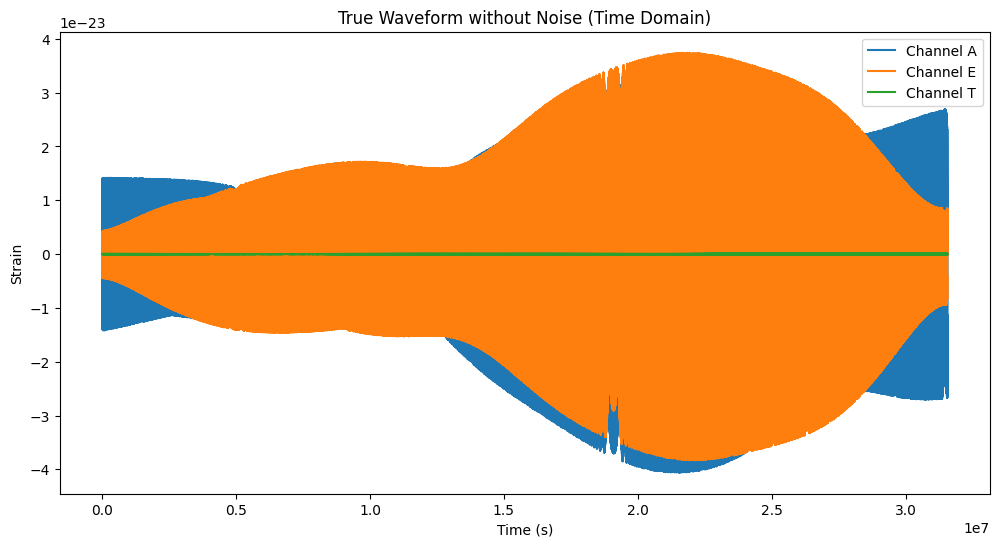

[INFO] Added noise to true waveform FFT

shape of waveform_true_fft after noise addition: (3, 3155814)


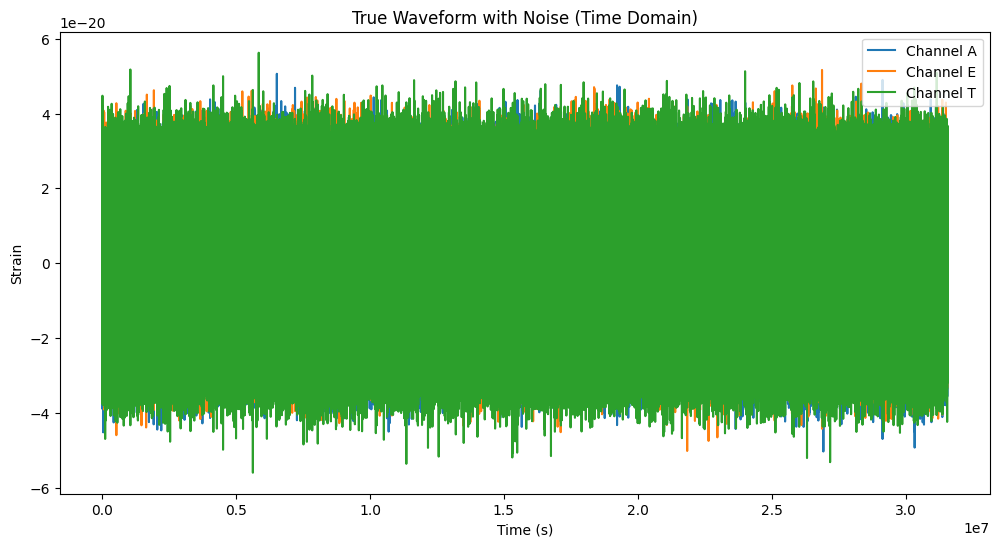

Length of PSD: 3155814


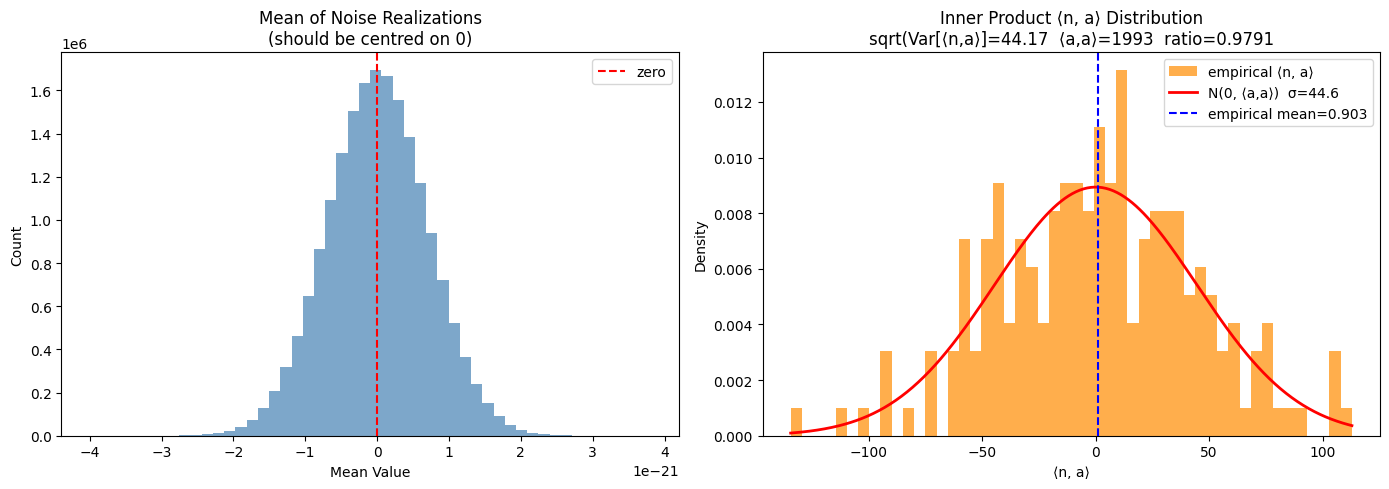

  Noise model consistency check
  Backend                : CuPy (GPU)
  Realizations           : 200
  N time samples         : 6311626  |  PSD bins passed: 3155813
  N (template samples)   : 6311629  →  aligned to 6311626
  Max |mean noise|       : 4.0032e-21  (expect ≈ 0)
  E[⟨n, a⟩]             : 9.0326e-01           (expect ≈ 0)
  Var[⟨n, a⟩]           : 1950.89
  ⟨a, a⟩                : 1992.53
  Ratio Var/⟨a,a⟩       : 0.979106          (expect ≈ 1.0)
Noise consistency check results: {'mean_noise': array([[-8.68921176e-22,  3.54543943e-22,  2.52559991e-22, ...,
         6.30125341e-22, -5.83403466e-22,  7.10403505e-22],
       [-2.08924216e-23,  4.32156119e-24,  1.78857121e-22, ...,
         1.02424805e-21,  2.71873085e-23,  2.46304456e-22],
       [ 5.81954774e-22, -8.54387829e-23,  7.93659288e-23, ...,
         1.00137071e-21, -1.06712954e-21, -1.78807266e-22]],
      shape=(3, 6311626)), 'inner_products': array([ 1.88766651e+01, -4.71163287e+01,  5.15812769e+01,  3.41924805e+0

{'m1': np.float64(1000000.0),
 'm2': np.float64(10.0),
 'a': np.float64(0.9),
 'p0': np.float64(7.5),
 'e0': np.float64(0.5),
 'Y0': np.float64(1.0),
 'dist': np.float64(5.0),
 'qS': np.float64(0.7853981633974483),
 'phiS': np.float64(1.0),
 'qK': np.float64(1.0),
 'phiK': np.float64(1.0471975511965976),
 'Phi_phi0': np.float64(0.9),
 'Phi_theta0': np.float64(0.5),
 'Phi_r0': np.float64(0.4),
 'dt': 5,
 'T': 1.0,
 'chi2': 0.0,
 'dev_1': 0.0,
 'dev_2': 0.0,
 'waveform_response': <fastlisaresponse.response.ResponseWrapper at 0x1554cb197d70>,
 'PSD_funcs': array([[6.81763650e-35, 1.70440916e-35, 7.57515208e-36, ...,
         4.26636463e-39, 4.26636171e-39, 4.26635879e-39],
        [6.81763650e-35, 1.70440916e-35, 7.57515208e-36, ...,
         4.26636463e-39, 4.26636171e-39, 4.26635879e-39],
        [2.65994852e-56, 1.06395802e-55, 2.39388950e-55, ...,
         1.65107196e-39, 1.65106498e-39, 1.65105800e-39]],
       shape=(3, 3155814)),
 'waveform_true_fft': array([[-6.25689989e-15+4.0676

In [2]:
seed= 42   
param_names_to_infer = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0']  
params_name = ["m1","m2","a","p0","e0","xI0","dist","qS","phiS","qK","phiK",
                         "Phi_phi0","Phi_theta0","Phi_r0"]      

params = np.array([1e6,1e1,0.9, 7.5,  5.00000000e-01,  1.00000000e+00,
          5.0,  np.pi/4,  1.0, 1,  np.pi/3,  9.00000000e-01, 5.00000000e-01,  4.00000000e-01])

signal_param = {"m1": 1e6,
    "m2": 10.0,
    "a": 0.9,
    "p0": 7.5,
    "e0": 0.5,
    "xI0": 1.0,
    "dist": 5.0,
    "qS": np.pi/4,
    "phiS": 1,
    "qK": 1,
    "phiK": np.pi/3,
    "Phi_phi0": 0.9,
    "Phi_theta0": 0.5,
    "Phi_r0": 4.00000000e-01,
}
signal_param_array = np.array(list(signal_param.values()))
dt = 5  #Time step for waveform generation; default 0.1s
T= 1.0

chi2 = 0.0 
dev_1 = 0.0
dev_2 = 0.0

emri_kwargs = {"T": T, "dt": dt,'chi2': chi2,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': dev_1, 'dev_2': dev_2}
add_kwargs = {'chi2': chi2,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': dev_1, 'dev_2':  dev_2}

# if target_func in ('optimal_snr', 'optimal_snr_phase_max','time_max'):
        
ctx_10 = prepare_true_waveform(signal_param_array, emri_kwargs, add_kwargs,add_noise=True, use_gpu=True,seed=seed)

snr_2 = inner_prod(ctx_10['waveform_true_fft_without_noise'], ctx_10['waveform_true_fft_without_noise'], ctx_10['PSD_funcs'], ctx_10['delta_f'], xp=xp)
ctx_10

In [3]:
waveform_time_10 = ctx_10['waveform_time']
tdi_channels = ['A', 'E', 'T']
n_channels = len(tdi_channels)
PSD = ctx_10['PSD_funcs']
freq = ctx_10['freq'][1:]
# Strain sensitivity
plt.figure(figsize=(10, 5))
for i in range(n_channels):
    freq_plt = freq.get() if hasattr(freq, "get") else freq
    PSD_i = PSD[i].get() if hasattr(PSD[i], "get") else PSD[i]
    strain_sensitivity = np.sqrt(freq_plt * PSD_i)
    plot_frequency_series(
        freq_plt,
        strain_sensitivity,
        label=f"Strain Sensitivity - Channel {tdi_channels[i]}",
        xlabel="Frequency (Hz)",
        ylabel="Strain",
        show=False,
        clear=False
    )
plt.title("Strain Sensitivity (sqrt(f*PSD))")
plt.tight_layout()

for j in range(n_channels):
    emri_strain_waveform_i = np.abs(ctx_10["waveform_true_fft_without_noise"][j].get()) * freq_plt

    plot_frequency_series(
        freq_plt[1:],
        emri_strain_waveform_i[1:],
        xlabel="Frequency (Hz)",
        ylabel="Strain",
        show=False,
        clear=False,
        label=f"Channel {tdi_channels[j]}"
                )

plt.xlim(freq_plt[freq_plt > 0].min(), freq_plt.max())
plt.title(f"EMRI Waveform - Source {i + 1}")
plt.tight_layout()
plt.show()
plt.clf()




KeyError: 'waveform_time'